In [4]:
import numpy as np
import pickle
import pandas as pd
from loguru import logger
import matplotlib.pyplot as plt


In [5]:
test_flows = pd.read_csv('./interm/unsw_nb15_processed_test.csv')

In [6]:
len(test_flows)

448587

In [9]:
metrics_dir = './interm/xAI/GNNE_20260309_132324/experiment.pkl'
with open(metrics_dir, 'rb') as f:
	explainability_report = pickle.load(f)

In [10]:
explainability_report.keys()

dict_keys(['meta', 'description', 'results'])

In [11]:
explainability_report['meta'].keys(), explainability_report['results'].keys(), 

(dict_keys(['args', 'model_dir', 'test_f', 'metrics_output_dir']),
 dict_keys(['mask', 'losses', 'mask_regularization']))

In [12]:
explainability_report['results']['mask']

tensor([0.2665, 0.2665, 0.2665,  ..., 0.2665, 0.3172, 0.2665],
       requires_grad=True)

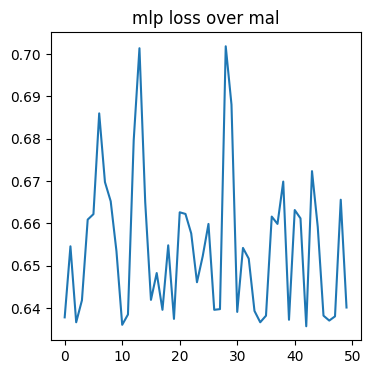

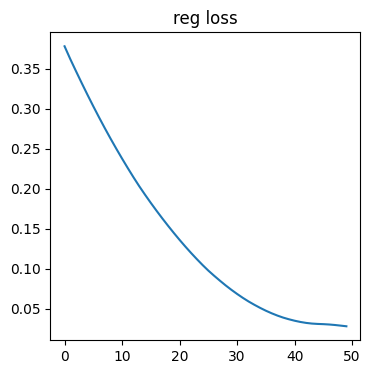

In [13]:
plt.figure(figsize=(4,4))
losses, reg_losses = explainability_report['results']['losses'], explainability_report['results']['mask_regularization']

plt.plot([l - r for l,r in zip(losses, reg_losses)])
plt.title('mlp loss over mal')
plt.show()

plt.figure(figsize=(4,4))
plt.plot(reg_losses)
plt.title('reg loss')
plt.show()

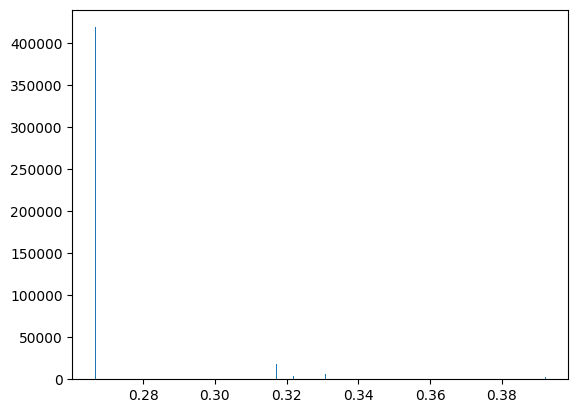

In [14]:
mask = explainability_report['results']['mask'].detach().numpy()
plt.hist(mask, bins=500)
plt.show()

In [16]:
import pickle
from pathlib import Path
from EGraphSAGE import EGraphSAGE

with open(Path(explainability_report['meta']['model_dir']), 'rb')as f:
	model = pickle.load(f)


In [19]:
from ML_utils import graph_encode, fidelities
import torch

# convert test_flows Attack to binary
test_flows["Attack"] = torch.Tensor(
	(test_flows["Attack"] != "Benign").astype(float).values
).float()

G, _ = graph_encode(test_flows, edge_cols=['src','dst'], linegraph=False, target_col='Attack')

C:\Users\joelh\AppData\Local\Temp\ipykernel_24612\2677428937.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ..\torch\csrc\utils\tensor_numpy.cpp:212.)
  test_flows["Attack"] = torch.Tensor(


In [ ]:
sparsities=np.arange(0, 0.4, 0.02)
from tqdm import tqdm

fps, fms, threshes = [], [], []
for s in tqdm(sparsities, desc=f"Evaluating masks at spasities"):
	threshold = np.percentile(mask, s * 100)

	masked_y_pred_mean = ...

	
	binary_masked_y_pred = (masked_y_pred > 0.5).float()
	binary_y_pred = (y_pred > 0.5).float()
	fp, fm = fidelities(
		y_pred=binary_y_pred,
		y_mask=binary_masked_y_pred,
		y_imask=1 - binary_masked_y_pred,
		y=G.y,
	)

	fps.append(fp)
	fms.append(fm)
	threshes.append(threshes)


print('fp, fm, T')
plt.figure(figsize=(4,4)); plt.plot(fps); plt.show()
plt.figure(figsize=(4,4)); plt.plot(fms); plt.show()
plt.figure(figsize=(4,4)); plt.plot(threshes); plt.show()

Evaluating masks at spasities:   0%|          | 0/20 [00:00<?, ?it/s]


RuntimeError: The size of tensor a (512) must match the size of tensor b (448587) at non-singleton dimension 1

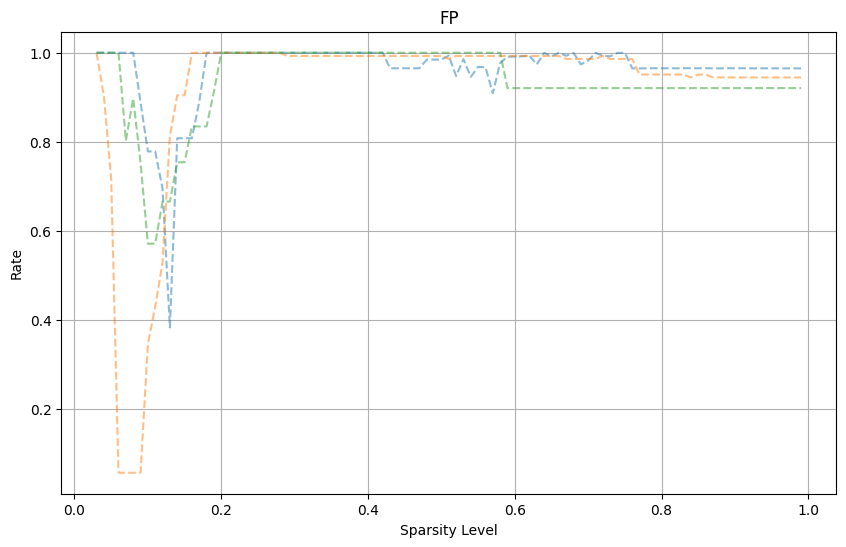

In [ ]:
windows_metrics = explainability_report['metrics_per_window']

# for each windows, plot a line graph for fn and fp (y) for each sparisity level (x), 
# have all window plots on the same graph, with a small line thickness ans transperancy
plt.figure(figsize=(10, 6))
	sparsities, fidelities = zip(*metrics.items())
	y = np.array([f['fp'] for f in fidelities])[3:]
	x = np.array(sparsities)[3:]
	plt.plot(x, y, label=f'Window {i+1} FP', linestyle='--', alpha=0.5, )

plt.xlabel('Sparsity Level')
plt.ylabel('Rate')
plt.title('FP')
plt.grid()
plt.show()

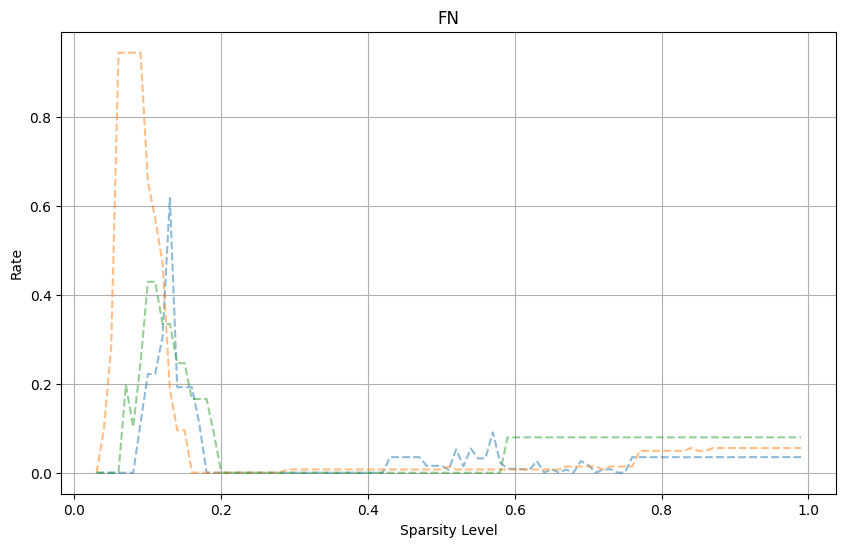

In [8]:
windows_metrics = explainability_report['metrics_per_window']

# for each windows, plot a line graph for fn and fp (y) for each sparisity level (x), 
# have all window plots on the same graph, with a small line thickness ans transperancy
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for i, metrics in enumerate(windows_metrics):
	sparsities, fidelities = zip(*metrics.items())
	y = np.array([f['fn'] for f in fidelities])[3:]
	x = np.array(sparsities)[3:]
	plt.plot(x, y, label=f'Window {i+1} FN', linestyle='--', alpha=0.5, )

plt.xlabel('Sparsity Level')
plt.ylabel('Rate')
plt.title('FN')
plt.grid()
plt.show()